In [1]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from gurobipy import quicksum
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import os

from functions import (plot_DA_week,
                    load_da_market_data,
                    load_fcr_prices,
                    plot_fcr_prices)

In [2]:
#Battery Parameters
battery_capacity = 40 #[MWh]
SOC_min = 1 #[Mwh]
charge_rate_min = 0 #[MW]
discharge_rate_min = 0 #[MW]
charge_rate_max = 10 #[MW]
discharge_rate_max = 10 #[MW]
efficiency = 0.99
self_discharge_rate = 0
initial_SOC = 20 #[MWh]

#Market Parameters:
    #DAM:
minimum_bid_DAM = 0.1 #[MW]
granularity_DAM = 1 #hours

In [4]:
# Load Day-Ahead Market Prices
da_folder = "data/energy-charts_day_ahead"
years_to_load = [2024]  # available years span 2015-2024

# Load Day-Ahead Market Prices
DA_prices_merged = load_da_market_data(da_folder, years_to_load)
DA_prices_merged["timestamp"] = pd.to_datetime(DA_prices_merged["timestamp"])
DA_prices_merged["timestamp"] = DA_prices_merged["timestamp"] + pd.Timedelta(hours=1) # shift by one hour to fit local time
DA_prices_merged = DA_prices_merged.sort_values("timestamp").reset_index(drop=True)
DA_prices_merged["delivery_day"] = DA_prices_merged["timestamp"].dt.floor("D") # create delivery day column

print(f"Loaded {len(DA_prices_merged)} hourly day-ahead price points.")
print(DA_prices_merged.head())

Loaded 8784 hourly day-ahead price points.
                  timestamp  price_eur_mwh              delivery_day
0 2024-01-01 00:00:00+00:00          25.97 2024-01-01 00:00:00+00:00
1 2024-01-01 01:00:00+00:00          21.99 2024-01-01 00:00:00+00:00
2 2024-01-01 02:00:00+00:00          14.32 2024-01-01 00:00:00+00:00
3 2024-01-01 03:00:00+00:00          11.37 2024-01-01 00:00:00+00:00
4 2024-01-01 04:00:00+00:00          11.35 2024-01-01 00:00:00+00:00


In [5]:
# Day-Ahead Market Optimization Model

def solve_day_ahead(
    prices_block,
    initial_soc,
    *,
    granularity_hours=1,
    battery_capacity=40.0,
    soc_min=1.0,
    charge_rate_bounds=(0.0, 10.0),
    discharge_rate_bounds=(0.0, 10.0),
    efficiency=0.99,
    self_discharge_rate=0.0,
    minimum_bid_volume=0.1,
    n_bid_slots=10,
    time_limit_seconds=60,
    gurobi_output=False,
    terminal_soc_target=None,
):
    
    clearing_price = prices_block["price_eur_mwh"].to_numpy(dtype=float)
    if len(clearing_price) == 0:
        raise ValueError("No price data provided for the horizon.")
    horizon = list(range(len(clearing_price)))  # power slots
    soc_slots = list(range(len(clearing_price) + 1))  # SOC slots (plus one for last timestep)

    MMO = gp.Model("DA_dispatch")
    MMO.Params.OutputFlag = 1 if gurobi_output else 0
    MMO.Params.TimeLimit = time_limit_seconds

    charge_lb, charge_ub = charge_rate_bounds
    discharge_lb, discharge_ub = discharge_rate_bounds
    side = ("Buy", "Sell")

    #Charging Variables
    Charge = MMO.addVars(
        horizon, vtype=GRB.CONTINUOUS, lb=charge_lb, ub=charge_ub, name="Battery_Charge"
    )
    Discharge = MMO.addVars(
        horizon, vtype=GRB.CONTINUOUS, lb=discharge_lb, ub=discharge_ub, name="Battery_Discharge"
    )
    ChargingIndicator = MMO.addVars(horizon, vtype=GRB.BINARY, name="Charging_Indicator")
    
    # State of Charge Variable
    SOC = MMO.addVars(
        soc_slots,
        vtype=GRB.CONTINUOUS,
        lb=soc_min,
        ub=battery_capacity,
        name="Battery_State_Of_Charge",
    )

    # Day-Ahead Market Bid Variables
    Bids = range(n_bid_slots)
    DAM_Bid_Price = MMO.addVars(
        horizon, Bids, side, vtype=GRB.CONTINUOUS, lb=0, name="DA_Bid_Price"
    )
    DAM_Bid_Volume = MMO.addVars(
        horizon, Bids, side, vtype=GRB.CONTINUOUS, lb=0, name="DA_Bid_Volume"
    )
    DAM_Bid_Placement = MMO.addVars(
        horizon, Bids, side, vtype=GRB.BINARY, name="DA_Bid_Placement"
    )
    DAM_Bid_Activation = MMO.addVars(
        horizon, Bids, side, vtype=GRB.BINARY, name="DA_Bid_Activation"
    )
    DAM_Executed_Volume = MMO.addVars(
        horizon, Bids, side, vtype=GRB.CONTINUOUS, lb=0, name="DA_Executed_Volume"
    )

    # Constraints for SOC dynamics
    MMO.addConstr(SOC[0] == initial_soc)

    for t in horizon:
        MMO.addConstr(
            SOC[t + 1]
            == (1 - self_discharge_rate) * SOC[t]
            + granularity_hours
            * (efficiency * Charge[t] - (1 / efficiency) * Discharge[t])
        )

    # Terminal SOC constraint
    if terminal_soc_target is not None:
        MMO.addConstr(SOC[soc_slots[-1]] == terminal_soc_target)

    # Day-Ahead Market Bid Constraints
    for t in horizon:
        for slot in Bids:
            MMO.addConstr(
                DAM_Bid_Placement[t, slot, "Buy"] + DAM_Bid_Placement[t, slot, "Sell"] <= 1
            )

            MMO.addGenConstrIndicator(
                DAM_Bid_Activation[t, slot, "Buy"],
                True,
                DAM_Bid_Price[t, slot, "Buy"] >= clearing_price[t],
            )
            MMO.addGenConstrIndicator(
                DAM_Bid_Activation[t, slot, "Buy"],
                False,
                DAM_Bid_Price[t, slot, "Buy"] <= clearing_price[t],
            )
            MMO.addConstr(
                DAM_Bid_Activation[t, slot, "Buy"] <= DAM_Bid_Placement[t, slot, "Buy"]
            )

            MMO.addGenConstrIndicator(
                DAM_Bid_Activation[t, slot, "Sell"],
                False,
                DAM_Bid_Price[t, slot, "Sell"] >= clearing_price[t],
            )
            MMO.addGenConstrIndicator(
                DAM_Bid_Activation[t, slot, "Sell"],
                True,
                DAM_Bid_Price[t, slot, "Sell"] <= clearing_price[t],
            )
            MMO.addConstr(
                DAM_Bid_Activation[t, slot, "Sell"] <= DAM_Bid_Placement[t, slot, "Sell"]
            )

            for s in side:
                MMO.addConstr(
                    DAM_Bid_Placement[t, slot, s] * minimum_bid_volume
                    <= DAM_Bid_Volume[t, slot, s]
                )
                MMO.addGenConstrIndicator(
                    DAM_Bid_Activation[t, slot, s],
                    True,
                    DAM_Executed_Volume[t, slot, s] == DAM_Bid_Volume[t, slot, s],
                )
                MMO.addGenConstrIndicator(
                    DAM_Bid_Activation[t, slot, s],
                    False,
                    DAM_Executed_Volume[t, slot, s] == 0,
                )

        MMO.addConstr(
            Discharge[t]
            == quicksum(DAM_Executed_Volume[t, slot, "Sell"] for slot in Bids)
        )
        MMO.addConstr(
            Charge[t]
            == quicksum(DAM_Executed_Volume[t, slot, "Buy"] for slot in Bids)
        )
        MMO.addGenConstrIndicator(ChargingIndicator[t], True, Discharge[t] == 0)
        MMO.addGenConstrIndicator(ChargingIndicator[t], False, Charge[t] == 0)

    profit = quicksum(
        clearing_price[t] * (Discharge[t] - Charge[t]) * granularity_hours for t in horizon
    )

    MMO.setObjective(profit, GRB.MAXIMIZE)
    MMO.optimize()

    if MMO.Status not in {GRB.OPTIMAL, GRB.TIME_LIMIT}:
        raise RuntimeError(f"Model ended with status {MMO.Status}")

    schedule = {
        "charge": np.array([Charge[t].X for t in horizon]),
        "discharge": np.array([Discharge[t].X for t in horizon]),
        "soc": np.array([SOC[t].X for t in soc_slots]),
    }

    return {
        "status": MMO.Status,
        "objective_value": MMO.ObjVal if MMO.SolCount else None,
        "schedule": schedule,
        "terminal_soc": schedule["soc"][-1],
    }

In [7]:
# Rolling optimization across all delivery days

# Group prices by delivery day
prices_by_day = (
    DA_prices_merged
    .assign(delivery_day=lambda df: df["timestamp"].dt.floor("D"))
    .groupby("delivery_day", group_keys=False)
)

# Initialize state of charge
state_soc = initial_SOC
last_day = DA_prices_merged["delivery_day"].max()
daily_rows = []
hourly_rows = []

# Iterate through each delivery day
for delivery_day, block in prices_by_day:
    block = block.sort_values("timestamp").reset_index(drop=True) # sort by timestamp
    if len(block) == 0:
        print(f"Skipping {delivery_day.date()} -> no data available")
        continue

    target_soc = initial_SOC if delivery_day == last_day else None # set target SOC for last day only

    result = solve_day_ahead(
        block,
        state_soc,
        granularity_hours=granularity_DAM,
        battery_capacity=battery_capacity,
        soc_min=SOC_min,
        charge_rate_bounds=(charge_rate_min, charge_rate_max),
        discharge_rate_bounds=(discharge_rate_min, discharge_rate_max),
        efficiency=efficiency,
        self_discharge_rate=self_discharge_rate,
        minimum_bid_volume=minimum_bid_DAM,
        terminal_soc_target=target_soc,
        n_bid_slots=10,
        time_limit_seconds=60,
        gurobi_output=False,
    )

    state_soc = result["terminal_soc"] # update state of charge for next day

    schedule = result["schedule"]  # extract schedule
    net_export = schedule["discharge"] - schedule["charge"] # net export profile
    realized_profit = float(np.dot(block["price_eur_mwh"].to_numpy(), net_export) * granularity_DAM) # compute realized profit
    soc_profile = schedule["soc"] # state of charge profile
    
    # Populate hourly rows
    for t, ts in enumerate(block["timestamp"]): 
        hourly_rows.append(
            {
                "timestamp": ts,
                "delivery_day": delivery_day,
                "charge_mw": schedule["charge"][t],
                "discharge_mw": schedule["discharge"][t],
                "soc_mwh": soc_profile[t + 1],
                "soc_start_mwh": soc_profile[t],
                "price_eur_mwh": block["price_eur_mwh"].iloc[t],
            }
        )
    # Populate daily rows
    daily_rows.append(
        {
            "run_time": delivery_day - pd.Timedelta(hours=14),
            "delivery_day": delivery_day,
            "profit_model": result["objective_value"],
            "profit_recomputed": realized_profit,
            "terminal_soc": state_soc,
        }
    )

# Compile results
profit_df = pd.DataFrame(daily_rows).sort_values("delivery_day").reset_index(drop=True)
dispatch_df = pd.DataFrame(hourly_rows).sort_values("timestamp").reset_index(drop=True)
annual_profit = profit_df["profit_model"].sum()

print(f"Simulated {len(profit_df)} delivery days.")
print(f"Cumulative day-ahead profit: {annual_profit:,.2f} €")
profit_df.head()


Simulated 366 delivery days.
Cumulative day-ahead profit: 838,430.14 €


,run_time,delivery_day,profit_model,profit_recomputed,terminal_soc
0,2023-12-31 10:00:00+00:00,2024-01-01 00:00:00+00:00,1833.295350,1833.295350,1.0
1,2024-01-01 10:00:00+00:00,2024-01-02 00:00:00+00:00,2325.543248,2325.543248,1.0
2,2024-01-02 10:00:00+00:00,2024-01-03 00:00:00+00:00,2813.528804,2813.528804,1.0
3,2024-01-03 10:00:00+00:00,2024-01-04 00:00:00+00:00,2868.241824,2868.241824,1.0
4,2024-01-04 10:00:00+00:00,2024-01-05 00:00:00+00:00,1206.799988,1206.799988,1.0


## Extract Results

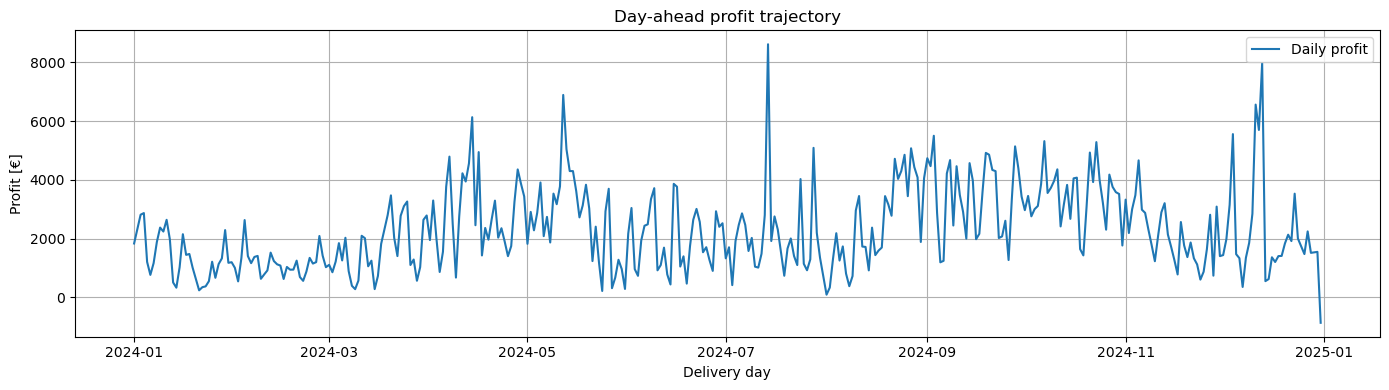

In [9]:
if profit_df.empty:
    print("No results to plot.")
else:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(profit_df["delivery_day"], profit_df["profit_model"], label="Daily profit")
    ax.set_ylabel("Profit [€]")
    ax.set_xlabel("Delivery day")
    ax.grid(True)
    ax.set_title("Day-ahead profit trajectory")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [10]:
def plot_dispatch(dispatch_df, *, week=None, day=None, start=None, end=None,
                  tz="UTC", view_tz="Europe/Zurich"):
    """
    Select one: week=<int>, day=<YYYY-MM-DD>, or start/end window.
    """
    if dispatch_df.empty:
        print("No dispatch trajectories available.")
        return

    modes = [week is not None, day is not None, (start is not None and end is not None)]
    if sum(modes) != 1:
        raise ValueError("Specify exactly one of `week`, `day`, or (`start`, `end`).")

    ts = pd.to_datetime(dispatch_df["timestamp"])
    if ts.dt.tz is None and tz:
        ts = ts.dt.tz_localize(tz)

    def to_view_local(series):
        return series.dt.tz_convert(view_tz).dt.tz_localize(None) if view_tz else series.tz_localize(None)

    if start is not None:
        start = pd.to_datetime(start)
        end = pd.to_datetime(end)
        if ts.dt.tz is not None:
            start = start.tz_localize(ts.dt.tz)
            end = end.tz_localize(ts.dt.tz)
        mask = (ts >= start) & (ts <= end)
        label = f"{start} → {end}"
    elif day is not None:
        day = pd.to_datetime(day)
        local_series = to_view_local(ts)
        mask = local_series.dt.normalize() == day.normalize()
        label = f"Day {day.date()}"
    else:
        hours_per_week = 24 * 7
        start_idx = (week - 1) * hours_per_week
        end_idx = start_idx + hours_per_week
        if end_idx > len(dispatch_df):
            print(f"Not enough data to plot week {week}. Available hours: {len(dispatch_df)}")
            return
        slice_df = dispatch_df.iloc[start_idx:end_idx]
        local_time = to_view_local(pd.to_datetime(slice_df["timestamp"]))
        return _plot_slice(slice_df.reset_index(drop=True), local_time, label=f"Week {week}")

    slice_df = dispatch_df.loc[mask]
    if slice_df.empty:
        print(f"No data found for the selected window ({label}).")
        return

    slice_df = slice_df.sort_values("timestamp").reset_index(drop=True)
    local_time = to_view_local(pd.to_datetime(slice_df["timestamp"]))
    _plot_slice(slice_df, local_time, label)


def _plot_slice(slice_df, local_time, label):
    charge = slice_df["charge_mw"]
    discharge = slice_df["discharge_mw"]
    soc = slice_df["soc_mwh"]
    price = slice_df["price_eur_mwh"]

    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    axs[0].fill_between(local_time, 0, charge, step='mid', alpha=0.4, color='blue', label='Charge [MW]')
    axs[0].fill_between(local_time, 0, -discharge, step='mid', alpha=0.4, color='red', label='Discharge [MW]')
    axs[0].plot(local_time, soc, color='black', linewidth=2, label='SOC [MWh]')
    axs[0].set_ylabel("Power [MW] / SoC [MWh]")
    axs[0].legend(loc='upper left')
    axs[0].grid(True)
    axs[0].set_title(f"Optimal BESS Schedule — {label}")

    axs[1].plot(local_time, price, color='green', linewidth=1.8)
    axs[1].set_ylabel("DA Price [€/MWh]")
    axs[1].grid(True)
    axs[1].set_xlabel(f"Time ({local_time.iloc[0].tzname() if hasattr(local_time.iloc[0], 'tzinfo') else 'local'})")

    plt.tight_layout()
    plt.show()



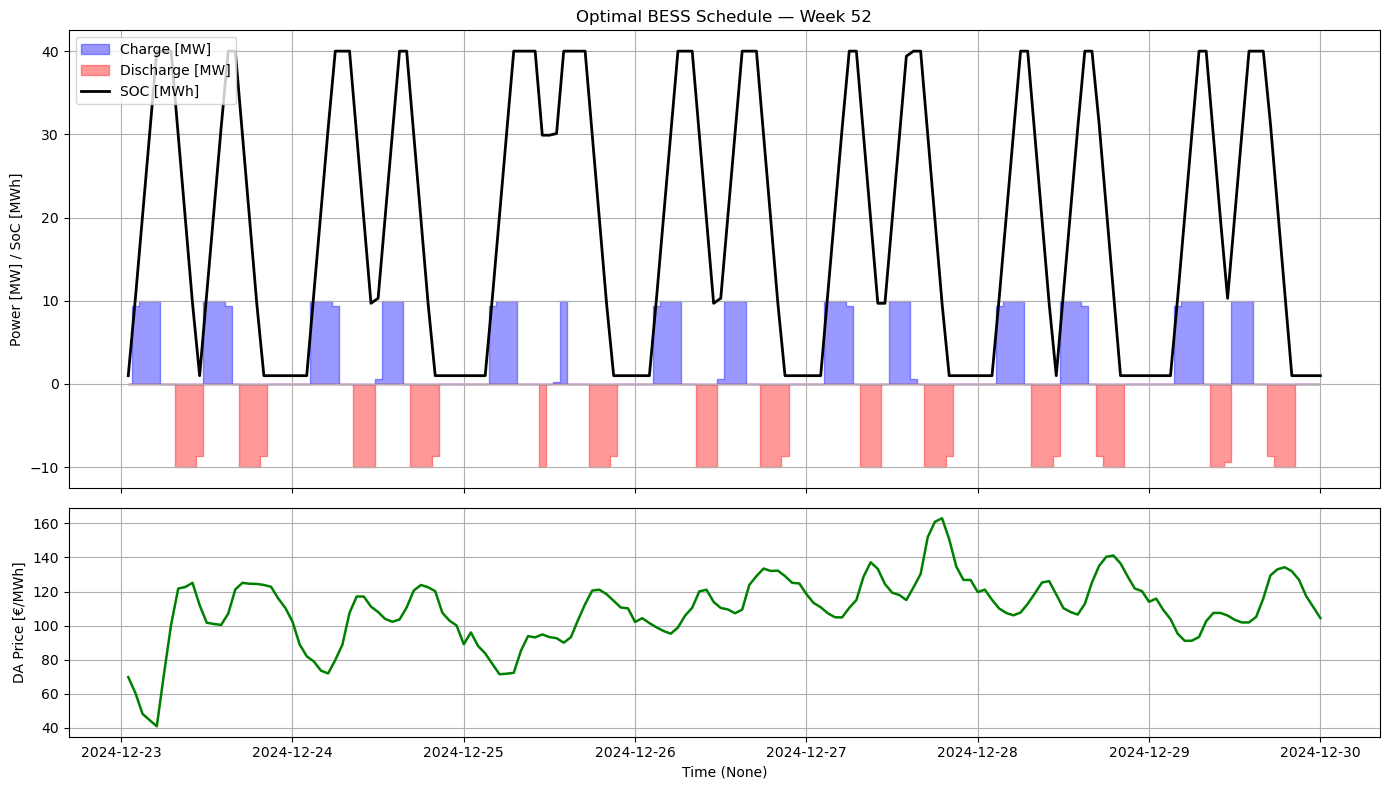

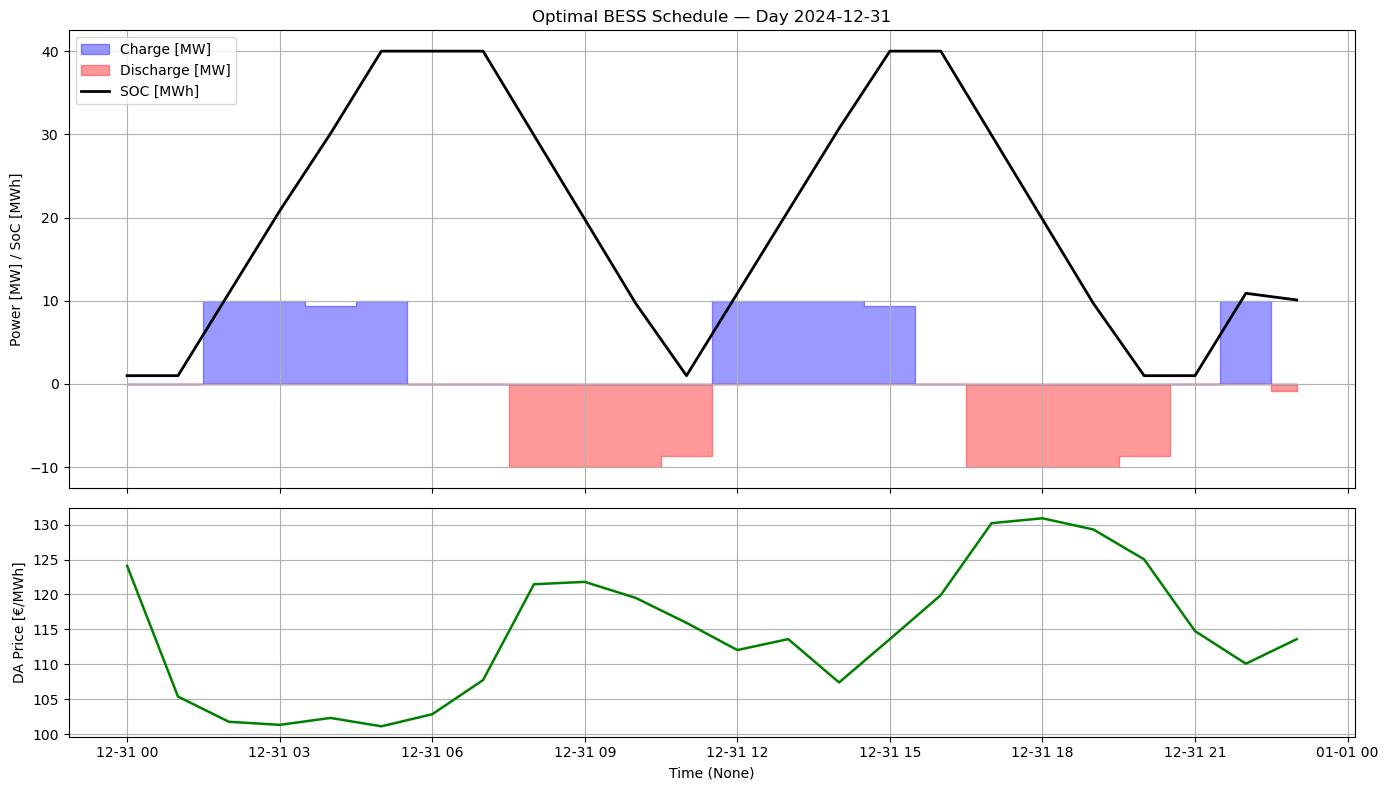

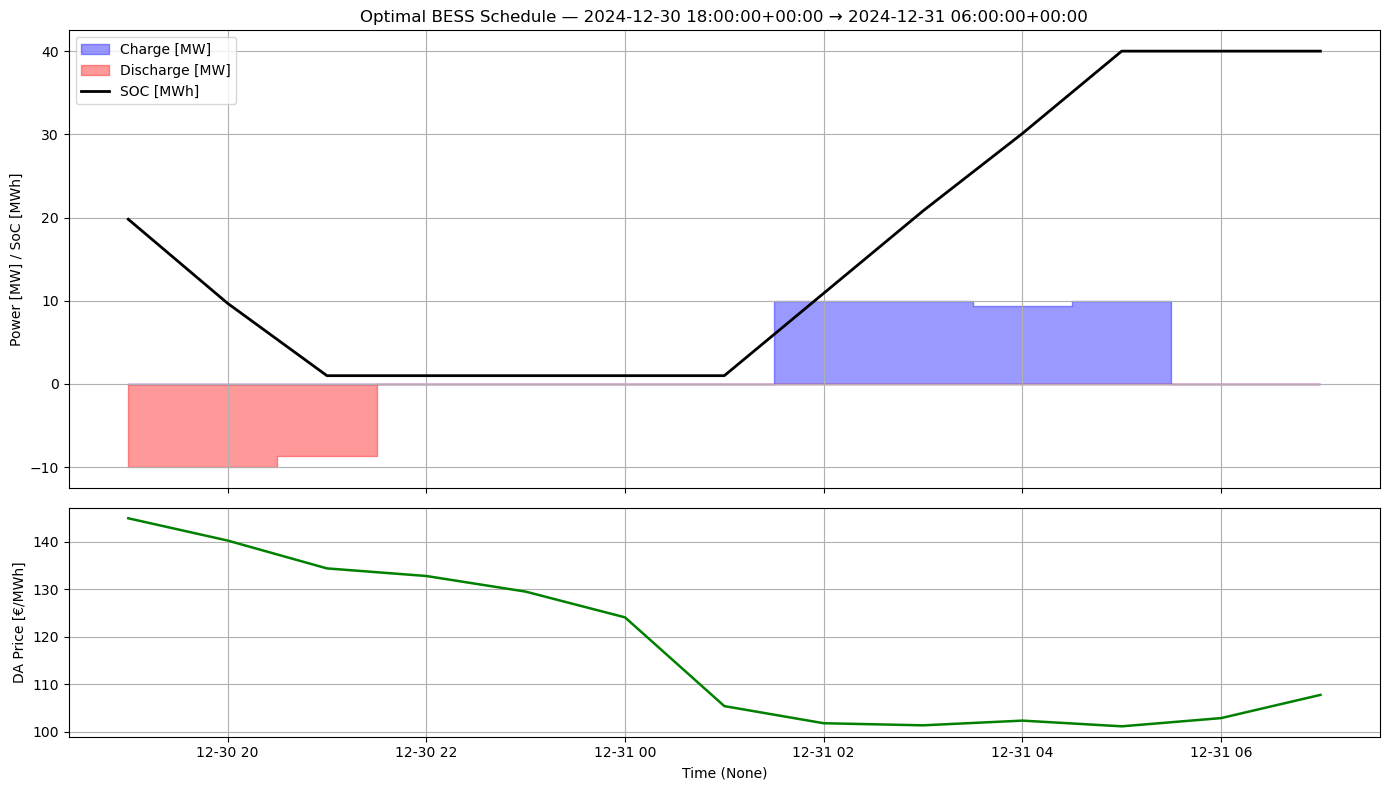

In [ ]:
plot_dispatch(dispatch_df, week=52)
plot_dispatch(dispatch_df, day="2024-12-31")
plot_dispatch(dispatch_df, start="2024-12-30 18:00", end="2024-12-31 06:00")